In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import random

In [2]:
# Read train, val, test
train_df = pd.read_csv("dataset/LSTM/train_lstm.csv")
val_df = pd.read_csv("dataset/LSTM/val_lstm.csv")
test_df = pd.read_csv("dataset/LSTM/test_lstm.csv")

In [3]:
train_df.head()

,period,idr_usd,inflation_rate,interest_rate,cond_vol
0,2015-01-05,12652.0,6.96,7.75,0.005032
1,2015-01-06,12721.0,6.96,7.75,0.005578
2,2015-01-07,12796.0,6.96,7.75,0.005540
3,2015-01-08,12795.0,6.96,7.75,0.005552
4,2015-01-09,12703.0,6.96,7.75,0.005242


In [4]:
val_df.head()

,period,idr_usd,inflation_rate,interest_rate,cond_vol
0,2022-01-03,14349.39,2.18,3.5,0.002599
1,2022-01-04,14341.35,2.18,3.5,0.002518
2,2022-01-05,14381.55,2.18,3.5,0.002442
3,2022-01-06,14436.83,2.18,3.5,0.002527
4,2022-01-07,14467.98,2.18,3.5,0.002729


In [59]:
test_df.head()

,period,idr_usd
0,2023-01-02,15669.96
1,2023-01-03,15649.86
2,2023-01-04,15667.95
3,2023-01-05,15693.08
4,2023-01-06,15688.05


## LSTM (Standalone - Feature: Raw Price) Modeling Pipeline

After splitting the dataset into training, validation, and test sets, the following steps are performed:

1. **Feature Scaling**  
   The input variables are normalized using a scaler fitted on the training set to ensure consistent feature ranges and avoid data leakage.

2. **Windowing (Sequence Creation)**  
   A sliding window approach with a 30-day lookback period is applied, where the model uses the previous 30 observations to predict the value on the next day.

3. **Data Reshaping**
   Reshape the input sequences into a three-dimensional structure, as expected by the LSTM model.
   
4. **Baseline Model Implementation**  
   A simple LSTM model is first implemented to establish a baseline performance for comparison.

5. **Hyperparameter Tuning (HPT)**  
   Hyperparameters such as the number of LSTM units, dropout rate, and learning rate are optimized using the validation set.

6. **Final Model Training**  
   The model is retrained using the best hyperparameters on the **combined training and validation datasets** to maximize the available learning data.

7. **Out-of-Sample Evaluation**  
   The final model is evaluated on the **test set (2023–2024)** to assess its predictive performance on unseen data.

## Scaling

In [60]:
# This code is used to find the min and max from the train set only
from sklearn.preprocessing import MinMaxScaler

# All values will be normalized, ranging between 0 and 1
# Fit hanya pada train to avoid data leakage / data bocor -> untuk mencari min dan max dari data training
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_df[['idr_usd']])

# Transform using min and max found in the code above
train_scaled = scaler.transform(train_df[['idr_usd']])
val_scaled   = scaler.transform(val_df[['idr_usd']])
test_scaled  = scaler.transform(test_df[['idr_usd']])

## Windowing

Windowing is applied to convert the time series data into sequential input suitable for the LSTM model. Instead of using individual observations, the model learns from a sequence of past values.

In this study, a **30-day lookback window** is used. This means the model takes the previous 30 observations as input to predict the value on the next day. By using this sliding window approach, the LSTM can capture temporal dependencies and short-term patterns in the exchange rate movements.

Simulation:

[Day 1 – Day 30] → predict Day 31

[Day 2 – Day 31] → predict Day 32

[Day 3 – Day 32] → predict Day 33

...

In [61]:
def create_windowed_data(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30  # Predict price on day 31 based on prices from day 1 to 30 

X_train, y_train = create_windowed_data(train_scaled, WINDOW_SIZE)
X_val, y_val     = create_windowed_data(val_scaled, WINDOW_SIZE)
X_test, y_test   = create_windowed_data(test_scaled, WINDOW_SIZE)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1696, 30, 1)
y_train shape: (1696, 1)


## Data Reshaping

Before feeding the data into the LSTM model, the input sequences must be reshaped into a three-dimensional structure. LSTM networks expect inputs in the format:

(samples, timesteps, features)

- **samples** represent the number of sequences in the dataset  
- **timesteps** represent the length of the input sequence (30 days in this study)  
- **features** represent the number of variables used as input

Since the model uses a single variable (USD/IDR), the feature dimension equals one. Therefore, the input data is reshaped accordingly to match the required LSTM input format.

In [62]:
# Reshape untuk LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train reshaped:", X_train.shape)
print("X_val reshaped:", X_val.shape)
print("X_test reshaped:", X_test.shape)

X_train reshaped: (1696, 30, 1)
X_val reshaped: (216, 30, 1)
X_test reshaped: (447, 30, 1)


## Baseline Model Implementation

The purpose of the baseline model is to provide a benchmark that allows the performance of more optimized models to be evaluated in later stages. Specification:
- Unit: 50
- Dense: 1
- Optimizer: Adam
- Epochs: 50
- Batch size: 32

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

base_model = Sequential([
    LSTM(50, input_shape=(WINDOW_SIZE, 1)),  # units default 50, features = 1
    Dense(1)  # output : prediksi 1 nilai
])

# Compile model
base_model.compile(optimizer=Adam(), loss='mse')

# Fit model using default parameter
history_base = base_model.fit(
    X_train, y_train, # data training
    epochs=50, # dataset is iterated for 50 times
    batch_size=32, # update weights tiap 32 data
    validation_data=(X_val, y_val), # monitor performa model saat training -> using data validation
    verbose=1
)

# Evaluasi base model
base_eval = base_model.evaluate(X_test, y_test, verbose=0)
print("Base model test MSE:", base_eval)

Epoch 1/50


C:\Users\Aileen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0174 - val_loss: 0.0032
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 7.9145e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - val_loss: 5.3303e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 5.1271e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 6.0520e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 8.4107e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.4450e-04 - val_loss: 9.6738e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.7002e-04 - val_loss: 9.9034e-04
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.0936e-04 - val_loss: 9.9530e-04
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.6052e-04 - val_loss: 9.9034e-04
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.2096e-04 - val_loss: 9.7960e-04
Epoch 12/50
53/53 ━━━━

In [65]:
# Prediksi test set
y_test_pred = base_model.predict(X_test)

# Inverse transform ke skala asli
y_test_true = scaler.inverse_transform(y_test.reshape(-1,1))
y_test_pred_original = scaler.inverse_transform(y_test_pred)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_original))
mae  = mean_absolute_error(y_test_true, y_test_pred_original)
r2   = r2_score(y_test_true, y_test_pred_original)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R2: {r2:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Test RMSE: 116.3508
Test MAE: 101.6493
Test R2: 0.9286


## Hyperparameter Tuning (HPT)

After establishing the baseline model, hyperparameter tuning is conducted to improve model performance. This process involves systematically testing different configurations, such as the number of LSTM units, dropout rate, batch size, and learning rate.

The validation set is used to identify the combination of hyperparameters that yields the best performance before retraining the final model. Specification Range:
- Units: 32-128
- Dropout: 0.0, 0.2, 0.4
- Learning Rate: 0.01, 0.001, 0.0001
- Max Trials: 15 with 2 executions per trial

To prevent overfitting during training, **early stopping** is applied with a patience of **10 epochs**. This means that the training process will stop if the validation loss does not improve for 10 consecutive epochs, reducing the risk of overfitting while saving computational time.

In [67]:
from tensorflow.keras.models import Sequential
from kerastuner.tuners import RandomSearch
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

def build_model(hp):
    model = Sequential()
    
    # Hyperparameter: jumlah unit LSTM
    units = hp.Int('units', min_value=32, max_value=128, step=16)
    model.add(LSTM(units, return_sequences=False, input_shape=(WINDOW_SIZE, 1)))

    # Hyperparameter: Dropout
    dropout_rate = hp.Choice('dropout_rate', values=[0.0, 0.2, 0.4])
    model.add(Dropout(dropout_rate))
    
    # Hyperparameter: learning rate
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    
    return model

#TUNER SETUP
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=15,
    executions_per_trial=2)

# CALLBACK FOR EARLY STOPPING
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# EXECUTE TUNING
tuner.search(
    X_train, y_train,
    epochs=600,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# GET BEST MODEL
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print(best_hyperparameters.values)

# SUMMARY
best_model.summary()

Trial 15 Complete [00h 00m 51s]
val_loss: 0.0008055618382059038

Best val_loss So Far: 0.00011379848001524806
Total elapsed time: 00h 30m 47s
Best Hyperparameters:
{'units': 112, 'dropout_rate': 0.2, 'learning_rate': 0.01}


C:\Users\Aileen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 112)                 │          51,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             113 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,185 (199.94 KB)

 Trainable params: 51,185 (199.94 KB)

 Non-trainable params: 0 (0.00 B)

## Final Training

After identifying the best hyperparameters through the tuning process, the model is retrained using the **combined training and validation datasets**. This step allows the model to learn from a larger amount of data while maintaining the optimized configuration obtained from the tuning stage.

The retrained model is then used to generate predictions on the **test set (2023–2024)**, which represents unseen data and provides an unbiased evaluation of the model's predictive performance.

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Combine train & val sets
final_train_data = np.concatenate((train_scaled, val_scaled))
X_train_new, y_train_new = create_windowed_data(final_train_data, WINDOW_SIZE)

# Test data tetap dipakai untuk evaluasi
X_test, y_test = create_windowed_data(test_scaled, WINDOW_SIZE)

#Best parameters
units = 112
learning_rate = 0.01
dropout_rate = 0.2

model = Sequential([
    LSTM(units, return_sequences=False, input_shape=(WINDOW_SIZE, 1)),
    Dropout(dropout_rate),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

# CALLBACK FOR EARLY STOPPING
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_new, y_train_new,
    epochs=600,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Prediksi
y_train_pred = model.predict(X_train_new)
y_test_pred = model.predict(X_test)

# Kembali ke skala asli
y_train_true = scaler.inverse_transform(y_train_new.reshape(-1,1))
y_train_pred_original = scaler.inverse_transform(y_train_pred)

y_test_true = scaler.inverse_transform(y_test.reshape(-1,1))
y_test_pred_original = scaler.inverse_transform(y_test_pred)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_original))
mae = mean_absolute_error(y_test_true, y_test_pred_original)
r2 = r2_score(y_test_true, y_test_pred_original)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R2: {r2:.4f}")

Epoch 1/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0144
Epoch 2/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0011
Epoch 3/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 9.0854e-04
Epoch 4/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 8.8528e-04
Epoch 5/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 8.1970e-04
Epoch 6/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.2980e-04
Epoch 7/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.3702e-04
Epoch 8/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.3893e-04
Epoch 9/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 6.4942e-04
Epoch 10/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.9193e-04
Epoch 11/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 7.4981e-04
Epoch 12/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.5223e-04
Epoch 13/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 6.1855e-04
Epoch 14/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.3248e-04
Epoch 15/

NameError: name 'test_lstm' is not defined

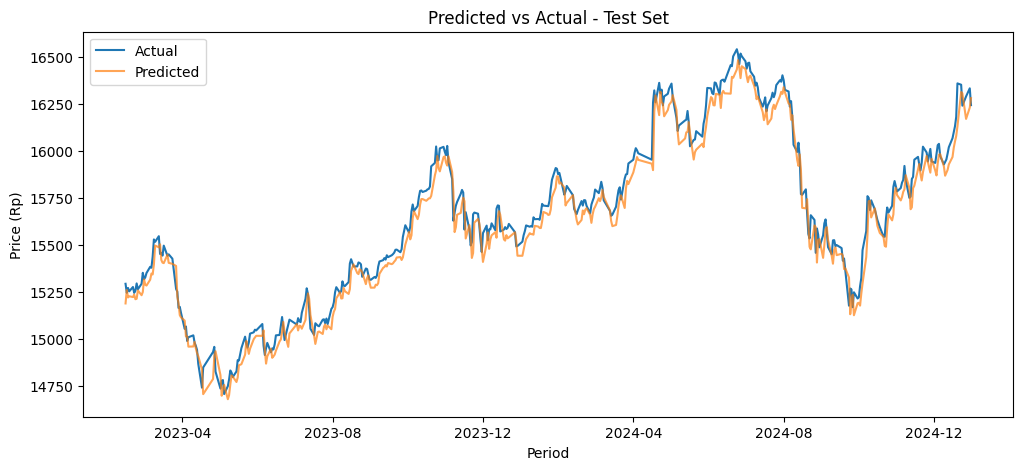

In [80]:
import matplotlib.dates as mdates

test_dates = pd.to_datetime(test_df['period'].iloc[WINDOW_SIZE:])

plt.figure(figsize=(12,5))
plt.plot(test_dates, y_test_true, label='Actual')
plt.plot(test_dates, y_test_pred_original, label='Predicted', alpha=0.7)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # format YYYY-MM

plt.title("Predicted vs Actual - Test Set")
plt.xlabel("Period")
plt.ylabel("Price (Rp)")
plt.legend()

## Out-of-Sample Performance: Baseline vs Tuned LSTM

To evaluate how well the LSTM captures USD/IDR dynamics, the **baseline model** and the **tuned model** are compared on the **unseen test set (2023–2024)**. This step simulates a real forecasting scenario where the model encounters new data.

#### Baseline Model
The baseline model is trained only on the **training set (2015–2021)** with default parameters. Its performance metrics are:

- RMSE: 116.35  
- MAE: 101.65  
- R²: 0.9286  

These results serve as a **reference point**, showing how well a simple LSTM can perform without optimization.

#### Tuned LSTM Model
The tuned model uses the **best hyperparameters** identified via validation (2022–2023) and is retrained on **both training and validation sets**. Its out-of-sample performance is:

- RMSE: 77.04  
- MAE: 63.57  
- R²: 0.9687  

Compared to the baseline, the tuned model:

1. **Reduces prediction errors** (lower RMSE and MAE)  
2. **Better explains variance** (higher R²)  
3. Demonstrates the **value of hyperparameter tuning** and including more historical data during training.

#### Key Takeaways
- The improvement in metrics highlights that the **LSTM can effectively capture temporal patterns** in USD/IDR when properly tuned.  
- Using **train + validation for final training** maximizes available information while keeping the test set truly unseen.

In [81]:
# Simpan the best baseline model (tuned)
model.save("model/best_model_lstm.keras")
print("💾 Model saved as best_model_lstm.keras")

💾 Model saved as best_model_lstm.keras
